#   Q18 Machine Learning Rolling Basis

In this example we predict whether the price will rise or fall by using supervised learning (Bayesian Ridge Regression). This template represents a starting point for developing a system which can take part to the **Q18 NASDAQ-100 Stock Long-Short contest**.

It consists of two parts.

* In the **first part** we just perform a global training of the time series using all time series data. We disregard the sequential aspect of the data and use also future data to train past data.

* In the **second part** we use the built-in backtester and perform training and prediction on a rolling basis in order to avoid forward looking. Please note that we are using a **specialized** version of the Quantiacs backtester which dramatically speeds up the the backtesting process by retraining your model on a regular basis.

**Features for learning**: we will use several technical indicators trying to capture different features. You can have a look at [**Technical Indicators**](https://quantiacs.com/documentation/en/user_guide/technical_indicators.html).

Please note that:

* Your trading algorithm can open short and long positions.

* At each point in time your algorithm can trade all or a subset of the stocks which at that point of time are or were part of the NASDAQ-100 stock index. Note that the composition of this set changes in time, and Quantiacs provides you with an appropriate filter function for selecting them.

* The Sharpe ratio of your system since January 1st, 2006, has to be larger than 1.

* Your system cannot be a copy of the current examples. We run a correlation filter on the submissions and detect duplicates.

* For simplicity we will use a single asset. It pays off to use more assets, ideally uncorrelated, and diversify your positions for a more solid Sharpe ratio.

More details on the rules can be found [here](https://quantiacs.com/contest).

**Need help?** Check the [**Documentation**](https://quantiacs.com/documentation/en/) and find solutions/report problems in the [**Forum**](https://quantiacs.com/community/categories) section.

**More help with Jupyter?** Check the official [**Jupyter**](https://jupyter.org/) page.

Once you are done, click on **Submit to the contest** and take part to our competitions.

API reference:

* **data**: check how to work with [data](https://quantiacs.com/documentation/en/reference/data_load_functions.html);

* **backtesting**: read how to run the [simulation](https://quantiacs.com/documentation/en/reference/evaluation.html) and check the results.

Need to use the optimizer function to automate tedious tasks?

* **optimization**: read more on our [article](https://quantiacs.com/community/topic/29/optimizing-and-monitoring-a-trading-system-with-quantiacs).

In [ ]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) { return false; }
// disable widget scrolling

In [1]:
import logging

import xarray as xr  # xarray for data manipulation

import qnt.data as qndata     # functions for loading data
import qnt.backtester as qnbt # built-in backtester
import qnt.ta as qnta         # technical analysis library
import qnt.stats as qnstats   # statistical functions

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

np.seterr(divide = "ignore")

from qnt.ta.macd import macd
from qnt.ta.rsi  import rsi
from qnt.ta.stochastic import stochastic_k, stochastic, slow_stochastic

from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error

In [2]:
# loading nasdaq-100 stock data
# stock_data = qndata.stocks.load_ndx_data(tail = (365 * 5), assets = ["NAS:AAPL", "NAS:AMZN"])

stock_data = qndata.stocks.load_spx_data(min_date="2005-01-01", assets=[
    "NAS:AAPL",  # Apple Inc.
    "NAS:NVDA",  # NVIDIA Corporation
    "NAS:AMZN",  # Amazon.com, Inc.
    "NAS:NFLX",  # Netflix, Inc.
    "NAS:MNST",  # Monster Beverage Corporation
    "NAS:MSFT",  # Microsoft Corporation
    "NAS:GOOGL", # Alphabet Inc. (Google)
    "NAS:AVGO",  # Broadcom Inc.
    "NAS:AMD",   # Advanced Micro Devices, Inc.
    "NAS:ISRG",  # Intuitive Surgical, Inc.
    "NAS:IDXX",  # IDEXX Laboratories, Inc.
    "NAS:ADBE",  # Adobe Inc.
    "NAS:INTU",  # Intuit Inc.
    "NAS:PYPL",  # PayPal Holdings, Inc.
    "NAS:DXCM",  # Dexcom, Inc.
    "NAS:ILMN",  # Illumina, Inc.
    "NAS:ROST",  # Ross Stores, Inc.
    "NAS:REGN",  # Regeneron Pharmaceuticals, Inc.
    "NAS:TSLA",  # Tesla, Inc.
    "NAS:PEP"    # PepsiCo, Inc.
])

# ---------------------------------------------------------------------------------

# stock_data = qndata.stocks.load_spx_data(min_date="2005-01-01")

100% (367973 of 367973) |################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (79197 of 79197) |##################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (6172800 of 6172800) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


fetched chunk 1/1 0s
Data loaded 1s


In [3]:
def get_features(data):
    """Builds the features used for learning:
       * a trend indicator;
       * the moving average convergence divergence;
       * a volatility measure;
       * the stochastic oscillator;
       * the relative strength index;
       * the logarithm of the closing price.
       These features can be modified and new ones can be added easily.
    """

    #Moving Averages
    close = data.sel(field='close')
    sma_slow = qnta.sma(close, 20)
    sma_fast = qnta.sma(close, 5)
    weights = xr.where(sma_slow < sma_fast, 1, -1)
    
    
    # trend:
    trend = qnta.roc(qnta.lwma(data.sel(field="close"), 60), 1)

    # moving average convergence  divergence (MACD):
    macd = qnta.macd(data.sel(field="close"))
    macd2_line, macd2_signal, macd2_hist = qnta.macd(data, 12, 26, 9)

    # volatility:
    volatility = qnta.tr(data.sel(field="high"), data.sel(field="low"), data.sel(field="close"))
    volatility = volatility / data.sel(field="close")
    volatility = qnta.lwma(volatility, 14)

    # the stochastic oscillator:
    k, d = qnta.stochastic(data.sel(field="high"), data.sel(field="low"), data.sel(field="close"), 14)

    # the relative strength index:
    rsi = qnta.rsi(data.sel(field="close"))

    # the logarithm of the closing price:
    price = data.sel(field="close").ffill("time").bfill("time").fillna(0) # fill NaN
    price = np.log(price)

    

    # combine the six features:
    result = xr.concat(
        [weights, trend, macd2_signal.sel(field="close"), volatility,  d, rsi, price],
        pd.Index(
            ["weight","trend",  "macd", "volatility", "stochastic_d", "rsi", "price"],
            name = "field"
        )
    )

    return result.transpose("time", "field", "asset")

In [4]:
# displaying the features:
my_features = get_features(stock_data)
display(my_features.sel(field="trend").to_pandas())

asset,NAS:AAPL,NAS:ADBE,NAS:AMD,NAS:AMZN,NAS:AVGO,NAS:DXCM,NAS:GOOGL,NAS:IDXX,NAS:ILMN,NAS:INTU,NAS:ISRG,NAS:MNST,NAS:MSFT,NAS:NFLX,NAS:NVDA,NAS:PEP,NAS:PYPL,NAS:REGN,NAS:ROST,NAS:TSLA
time,,,,,,,,,,,,,,,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-04,-0.068328,-0.236719,-0.261319,0.320909,0.289791,0.338410,0.349204,0.307555,NaN,-0.253918,0.190555,-0.360092,-0.129920,0.376509,-0.472119,-0.254984,-0.357504,-0.176906,-0.053079,0.059728
2025-02-05,-0.075044,-0.250533,-0.450467,0.224170,0.421227,0.377841,0.080305,0.327384,NaN,-0.270329,0.250119,-0.382340,-0.123194,0.419609,-0.315743,-0.199932,-0.302776,-0.076489,-0.044113,-0.073453
2025-02-06,-0.067029,-0.259220,-0.487028,0.255148,0.396696,0.344630,0.080633,0.259340,NaN,-0.255602,0.228018,-0.365821,-0.103165,0.420437,-0.214557,-0.200170,-0.325906,-0.044220,-0.100095,-0.116961


In [35]:
# def get_target_classes(data):
#     """ Target classes for predicting if price goes up or down."""

#     price_current = data.sel(field="close")
#     price_future  = qnta.shift(price_current, -1)

#     class_positive = 1 # prices goes up
#     class_negative = 0 # price goes down

#     target_price_up = xr.where(price_future > price_current, class_positive, class_negative)

#     return target_price_up

# -----------------------------------------------------------------COMPRAR Y VENDER -----------------------------------------------------------------------------------------

# def get_target_classes(data, sell_threshold=0.02):
#     """ Target classes for predicting if price goes up, down, or if we should sell.

#     Args:
#         data (xarray.DataArray): Dataset containing the price information.
#         sell_threshold (float): Percentage threshold to trigger a sell action when price is expected to drop significantly.

#     Returns:
#         xarray.DataArray: Array with target classes (1 for buy, 2 for sell, 0 for hold).
#     """

#     price_current = data.sel(field="close")
#     price_future = qnta.shift(price_current, -1)

#     class_positive = 1  # Price goes up (buy)
#     class_negative = 0  # Price stays the same (hold)
#     class_sell = 2      # Price drops significantly (sell)

#     # Calculate percentage change
#     percentage_change = (price_future - price_current) / price_current

#     # Define target classes
#     target_classes = xr.where(
#         percentage_change > 0, 
#         class_positive, 
#         xr.where(percentage_change < -sell_threshold, class_sell, class_negative)
#     )
#     return target_classes

# ----------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------------------------------------------------------------------------------------------

# def get_target_classes(data):
#     """ Target classes for predicting if price goes up or down."""

#     daily_return = qnta.change(data.sel(field="close")) / (data.sel(field="close"))
#     daily_return_future = daily_return.shift(time=-1)

#     move = 0.005

#     class_positive = 1  # Price goes more than move * 100%
#     class_neutral = 0   # Price does not move more than move * 100%
#     class_negative = -1 # Price goes down more than move * 100%

#     target_price = xr.where(daily_return_future < -move, class_negative, daily_return_future)
#     target_price = xr.where(target_price > move, class_positive, target_price)
#     target_price = xr.where(abs(target_price) != 1, class_neutral, target_price)

#     return target_price

# -------------------------------------------------------------------------------------------------------------------------------

def get_target_classes(data, move=0.005, volatility_window=14, rsi_period=14, rsi_buy=30, rsi_sell=70):
    """
    Estrategia optimizada para mejorar el Sharpe Ratio.
    Combina volatilidad, RSI y movimientos de precios.
    """
    # Retornos y precios futuros
    daily_return = qnta.change(data.sel(field="close")) / data.sel(field="close")
    daily_return_future = daily_return.shift(time=-1)

    # Cálculo de volatilidad
    volatility = data.sel(field="close").rolling(time=volatility_window).std()

    # Cálculo del RSI
    close_prices = data.sel(field="close")
    delta = close_prices.diff("time")
    gain = xr.where(delta > 0, delta, 0).rolling(time=rsi_period).mean()
    loss = xr.where(delta < 0, -delta, 0).rolling(time=rsi_period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    # Clases iniciales
    class_positive = 1  # Comprar
    class_negative = -1 # Vender
    class_neutral = 0   # Mantener

    # Compra y venta basadas en RSI y volatilidad
    target_price = xr.where(
        (daily_return_future > move) & (volatility < volatility.mean()) & (rsi < rsi_buy), class_positive, class_neutral
    )
    target_price = xr.where(
        (daily_return_future < -move) & (volatility < volatility.mean()) & (rsi > rsi_sell), class_negative, target_price
    )

    return target_price




In [36]:
# displaying the target classes:
my_targetclass = get_target_classes(stock_data)
display(my_targetclass.to_pandas())

asset,NAS:AAPL,NAS:ADBE,NAS:AMD,NAS:AMZN,NAS:AVGO,NAS:DXCM,NAS:GOOGL,NAS:IDXX,NAS:ILMN,NAS:INTU,NAS:ISRG,NAS:MNST,NAS:MSFT,NAS:NFLX,NAS:NVDA,NAS:PEP,NAS:PYPL,NAS:REGN,NAS:ROST,NAS:TSLA
time,,,,,,,,,,,,,,,,,,,,
2005-01-04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2005-01-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2005-01-06,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2005-01-07,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2005-01-10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-02-05,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-02-06,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [37]:
# from sklearn.ensemble import GradientBoostingRegressor
# def get_model():
#     """This is a constructor for the ML model (Gradient Boosting Regressor) which can be easily
#        modified for using different models.
#     """
#     model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
#     return model

# ---------------------------------------------------------------------------------------------------------------------------

# from sklearn.ensemble import HistGradientBoostingRegressor
# def get_model():
#     """This is a constructor for the ML model (HistGradientBoostingRegressor), which is optimized
#        for large datasets and supports additional features like monotonic constraints.
#     """
#     model = HistGradientBoostingRegressor(
#         learning_rate=0.1,      # Tasa de aprendizaje
#         max_iter=100,           # Iteraciones máximas (equivalente a n_estimators)
#         max_depth=7,            # Profundidad máxima de los árboles
#         random_state=42         # Semilla para reproducibilidad
#     )
#     return model

# ----------------------------------------------------------------------------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

def get_model():
    """This is a constructor for the ML model (Random Forest Regressor) which can be easily
       modified for using different models.
    """
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    return model


In [38]:
asset_name_all = stock_data.coords["asset"].values

models = dict()

for asset_name in asset_name_all:

        # drop missing values:
        target_cur = my_targetclass.sel(asset=asset_name).dropna(dim="time", how="any")
        features_cur = my_features.sel(asset=asset_name).dropna(dim="time", how="any")

        # align features and targets:
        target_for_learn_df, feature_for_learn_df = xr.align(target_cur, features_cur, join="inner")

        if len(features_cur.time) < 10:
            # not enough points for training
            continue

        model = get_model()

        try:
            model.fit(feature_for_learn_df.values, target_for_learn_df)
            models[asset_name] = model

        except Exception as e:
            logging.exception("Model training failed: %s", e)

print(models)


{'NAS:AAPL': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:ADBE': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:AMD': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:AMZN': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:AVGO': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:DXCM': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:GOOGL': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:IDXX': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:INTU': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:ISRG': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:MNST': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:MSFT': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:NFLX': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:NVDA': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:PEP': RandomForestRegressor(max_depth=10, random_state=42), 'NAS:PYPL'

Feature: 0, Score: 0.00646
Feature: 1, Score: 0.14311
Feature: 2, Score: 0.13201
Feature: 3, Score: 0.28069
Feature: 4, Score: 0.14606
Feature: 5, Score: 0.14942
Feature: 6, Score: 0.14224


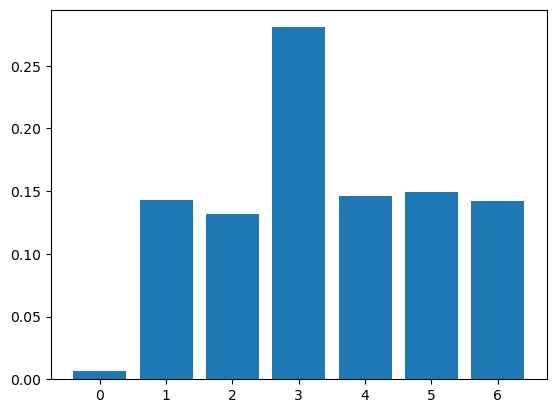

In [28]:

#---------------------------------------------------------------------------------------------

# Showing which features are more important in predicting:
importance = models["NAS:AAPL"].feature_importances_
# 
for i, v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i, v))

plt.bar([x for x in range(len(importance))], importance)
plt.show()


In [39]:
# Performs prediction and generates output weights:

asset_name_all = stock_data.coords["asset"].values
weights = xr.zeros_like(stock_data.sel(field="close"))

for asset_name in asset_name_all:
    if asset_name in models:
        model = models[asset_name]
        features_all = my_features
        features_cur = features_all.sel(asset=asset_name).dropna(dim="time", how="any")
        if len(features_cur.time) < 1:
            continue
        try:
            weights.loc[dict(asset=asset_name, time=features_cur.time.values)] = model.predict(features_cur.values)
        except KeyboardInterrupt as e:
            raise e
        except:
            logging.exception("model prediction failed")

# Filter for liquid assets
is_liquid = stock_data.sel(field="is_liquid")
weights = weights * is_liquid

# Ensure no NaN values in weights
weights = weights.fillna(0)  # Replace NaN values with 0

print(weights)


<xarray.DataArray 'stocks_s&p500' (time: 5059, asset: 20)> Size: 809kB
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-3.01590218e-05, -2.73597811e-05,  1.76838381e-03, ...,
        -9.95873759e-05,  6.44942313e-02,  1.12023767e-02],
       [ 9.16435512e-04, -2.73597811e-05,  0.00000000e+00, ...,
        -9.95873759e-05,  5.02766513e-02,  1.02702703e-02],
       [ 9.16435512e-04,  0.00000000e+00,  3.04166931e-03, ...,
         0.00000000e+00,  8.66348573e-02,  1.00000000e-02]])
Coordinates:
  * asset    (asset) <U9 720B 'NAS:AAPL' 'NAS:ADBE' ... 'NAS:ROST' 'NAS:TSLA'
  * time     (time) datetime64[ns] 40kB 2005-01-03 2005-01-04 ... 2025-02-10


In [40]:
def get_sharpe(stock_data, weights):
    """Calculates the Sharpe ratio"""
    rr = qnstats.calc_relative_return(stock_data, weights)
    sharpe = qnstats.calc_sharpe_ratio_annualized(rr).values[-1]
    return sharpe

sharpe = get_sharpe(stock_data, weights)
sharpe

3.7990116418549094

The sharpe ratio using the method above follows from **forward looking**. Predictions for (let us say) 2017 know about the relation between features and targets in 2020. Let us visualize the results:

field,equity,relative_return,volatility,underwater,max_drawdown,sharpe_ratio,mean_return,bias,instruments,avg_turnover,avg_holding_time
time,,,,,,,,,,,
2025-02-04,107326.507848,-0.000859,0.205796,-0.00309,-0.27809,3.797521,0.781513,0.735203,19.0,0.630693,2.232567
2025-02-05,107725.403288,0.003717,0.205775,0.00000,-0.27809,3.798504,0.781639,-0.268604,19.0,0.630605,2.232517
2025-02-06,108120.846654,0.003671,0.205755,0.00000,-0.27809,3.799468,0.781761,0.880890,19.0,0.630633,2.232492
2025-02-07,108173.346512,0.000486,0.205735,0.00000,-0.27809,3.799056,0.781600,0.871571,19.0,0.630716,2.232160
2025-02-10,108316.560152,0.001324,0.205715,0.00000,-0.27809,3.799012,0.781514,0.896008,19.0,0.630734,2.231950


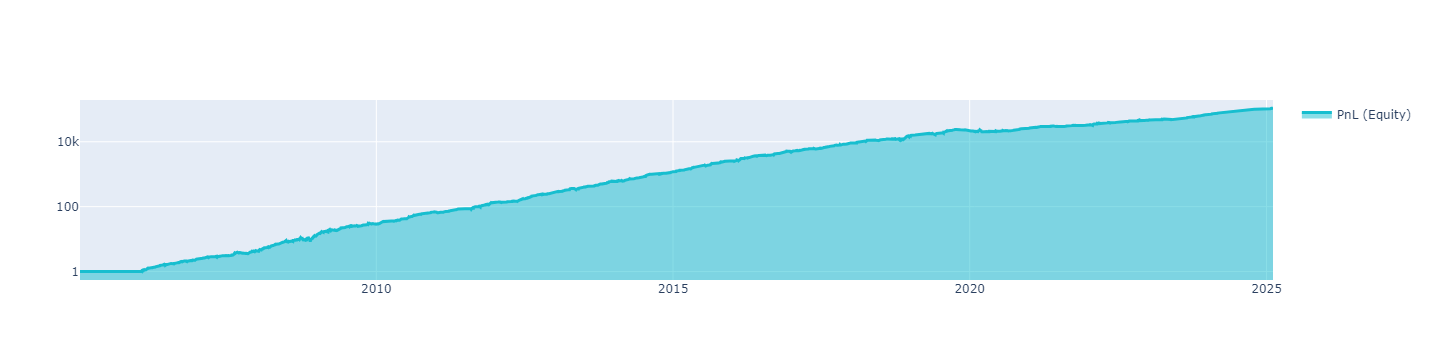

time,2025-02-10
field,
sharpe_ratio,3.799012



Ok. This strategy does not correlate with other strategies.


In [41]:
import qnt.graph as qngraph

statistics = qnstats.calc_stat(stock_data, weights)

display(statistics.to_pandas().tail())

performance = statistics.to_pandas()["equity"]
qngraph.make_plot_filled(performance.index, performance, name="PnL (Equity)", type="log")

display(statistics[-1:].sel(field = ["sharpe_ratio"]).transpose().to_pandas())

# check for correlations with existing strategies:
qnstats.print_correlation(weights,stock_data)

In [32]:
"""R2 (coefficient of determination) regression score function."""
r2_score(my_targetclass, weights, multioutput="variance_weighted")

#-------------------------------------------------------------------------

# # Ajusta las longitudes de my_targetclass y weights
# min_len = min(len(my_targetclass), len(weights))
# my_targetclass = np.ravel(my_targetclass[:min_len])
# weights = np.ravel(weights[:min_len])

# # Calcula el R2 Score
# r2 = r2_score(my_targetclass, weights, multioutput="variance_weighted")
# print("R2 Score:", r2)

0.33909667016153444

In [ ]:
"""The explained variance score explains the dispersion of errors of a given dataset"""
explained_variance_score(my_targetclass, weights, multioutput="uniform_average")

In [ ]:
"""The explained variance score explains the dispersion of errors of a given dataset"""
mean_absolute_error(my_targetclass, weights)

Let us now use the Quantiacs **backtester** for avoiding **forward looking**.

The backtester performs some transformations: it trains the model on one slice of data (using only data from the past) and predicts the weights for the following slice on a rolling basis:

In [ ]:
def train_model(data):
    """Create and train the model working on an asset-by-asset basis."""

    asset_name_all = data.coords["asset"].values
    features_all   = get_features(data)
    target_all     = get_target_classes(data)

    models = dict()

    for asset_name in asset_name_all:

        # drop missing values:
        target_cur   = target_all.sel(asset=asset_name).dropna(dim="time", how="any")
        features_cur = features_all.sel(asset=asset_name).dropna(dim="time", how="any")

        target_for_learn_df, feature_for_learn_df = xr.align(target_cur, features_cur, join="inner")

        if len(features_cur.time) < 10:
                continue

        model = get_model()

        try:
            model.fit(feature_for_learn_df.values, target_for_learn_df)
            models[asset_name] = model

        except:
            logging.exception("model training failed")

    return models

In [ ]:
def predict_weights(models, data):
    """The model predicts if the price is going up or down.
       The prediction is performed for several days in order to speed up the evaluation."""

    asset_name_all = data.coords["asset"].values
    weights = xr.zeros_like(data.sel(field="close"))

    for asset_name in asset_name_all:
        if asset_name in models:
            model = models[asset_name]
            features_all = get_features(data)
            features_cur = features_all.sel(asset=asset_name).dropna(dim="time", how="any")

            if len(features_cur.time) < 1:
                continue

            try:
                weights.loc[dict(asset=asset_name, time=features_cur.time.values)] = model.predict(features_cur.values)

            except KeyboardInterrupt as e:
                raise e

            except:
                logging.exception("model prediction failed")

    # Filter for liquid assets
    is_liquid = stock_data.sel(field="is_liquid")
    weights = weights * is_liquid

    # Ensure no NaN values in weights
    weights = weights.fillna(0)  # Replace NaN values with 0

    return weights

In [ ]:
# Calculate weights using the backtester:
weights = qnbt.backtest_ml(
    train                         = train_model,
    predict                       = predict_weights,
    train_period                  =  2 *365,  # the data length for training in calendar days
    retrain_interval              = 10 *365,  # how often we have to retrain models (calendar days)
    retrain_interval_after_submit = 1,        # how often retrain models after submission during evaluation (calendar days)
    predict_each_day              = False,    # Is it necessary to call prediction for every day during backtesting?
                                              # Set it to True if you suspect that get_features is looking forward.
    competition_type              = "stocks_s&p500",  # competition type
    lookback_period               = 365,                 # how many calendar days are needed by the predict function to generate the output
    # start_date                    = "2005-01-01",        # backtest start date
    start_date                    = "2006-01-01",
    analyze                       = True,
    build_plots                   = True  # do you need the chart?
)

The Sharpe ratio is obviously smaller as the training process is not looking forward (as it happens by processing data on a global basis), but performed on a rolling basis.

# May I import libraries?

Yes, please refer to the file **init.ipynb** in your home directory. You can for example use:

! conda install -y scikit-learn

# How to load data?

Daily stock data for the **Q18 Nasdaq-100** contest can be loaded using:
```python
data = qndata.stocks.load_ndx_data(tail = 17*365, dims = ("time", "field", "asset"))
```

Cryptocurrency daily data used for the Q16/Q17 contests can be loaded using:
```python
data = qndata.cryptodaily.load_data(tail = 17*365, dims = ("time", "field", "asset"))
```

Futures data for the Q15 contest can be loaded using:
```python
data= qndata.futures.load_data(tail = 17*365, dims = ("time", "field", "asset"))
```

BTC Futures data for the Q15 contest can be loaded using:
```python
data= qndata.cryptofutures.load_data(tail = 17*365, dims = ("time", "field", "asset"))
```

# How to view a list of all tickers?

```python
data.asset.to_pandas().to_list()
```

# How to see which fields are available?

```python
data.field.to_pandas().to_list()
```

# How to load specific tickers?

```python
data = qndata.stocks.load_ndx_data(tail=17 * 365, assets=["NAS:AAPL", "NAS:AMZN"])
```

# How to select specific tickers after loading all data?

```python
def get_data_filter(data, assets):
    filler= data.sel(asset=assets)
    return filler

get_data_filter(data, ["NAS:AAPL", "NAS:AMZN"])
```

# How to get the prices for the previous day?

```python
qnta.shift(data.sel(field="open"), periods=1)
```

or:

```python
data.sel(field="open").shift(time=1)
```

# How to get the Sharpe ratio?

```python
import qnt.stats as qnstats

def get_sharpe(market_data, weights):
    rr = qnstats.calc_relative_return(market_data, weights)
    sharpe = qnstats.calc_sharpe_ratio_annualized(rr).values[-1]
    return sharpe

sharpe = get_sharpe(data, weights) # weights.sel(time=slice("2006-01-01",None))
```

# How do I get a list of the top 3 assets ranked by Sharpe ratio?

```python
import qnt.stats as qnstats

data = qndata.stocks.load_ndx_data(tail = 17*365, dims = ("time", "field", "asset"))

def get_best_instruments(data, weights, top_size):
    # compute statistics:
    stats_per_asset = qnstats.calc_stat(data, weights, per_asset=True)
    # calculate ranks of assets by "sharpe_ratio":
    ranks = (-stats_per_asset.sel(field="sharpe_ratio")).rank("asset")
    # select top assets by rank "top_period" days ago:
    top_period = 1
    rank = ranks.isel(time=-top_period)
    top = rank.where(rank <= top_size).dropna("asset").asset

    # select top stats:
    top_stats = stats_per_asset.sel(asset=top.values)

    # print results:
    print("SR tail of the top assets:")
    display(top_stats.sel(field="sharpe_ratio").to_pandas().tail())

    print("avg SR = ", top_stats[-top_period:].sel(field="sharpe_ratio").mean("asset")[-1].item())
    display(top_stats)
    return top_stats.coords["asset"].values

get_best_instruments(data, weights, 3)
```

# How can I check the results for only the top 3 assets ranked by Sharpe ratio?

Select the top assets and then load their data:

```python
best_assets= get_best_instruments(data, weights, 3)

data= qndata.stocks.load_ndx_data(tail = 17*365, assets=best_assets)
```

# How can prices be processed?

Simply import standard libraries, for example **numpy**:

```python
import numpy as np

high= np.log(data.sel(field="high"))
```

# How can you reduce slippage impace when trading?

Just apply some technique to reduce turnover:

```python
def get_lower_slippage(weights, rolling_time=6):
    return weights.rolling({"time": rolling_time}).max()

improved_weights = get_lower_slippage(weights, rolling_time=6)
```

# How to use technical analysis indicators?

For available indicators see the source code of the library: /qnt/ta

## ATR

```python
def get_atr(data, days=14):
    high = data.sel(field="high") * 1.0
    low  = data.sel(field="low") * 1.0
    close= data.sel(field="close") * 1.0

    return qnta.atr(high, low, close, days)

atr= get_atr(data, days=14)
```

## EMA

```python
prices= data.sel(field="high")
prices_ema= qnta.ema(prices, 15)
```

## TRIX

```python
prices= data.sel(field="high")
prices_trix= qnta.trix(prices, 15)
```

## ADL and EMA

```python
adl= qnta.ad_line(data.sel(field="close")) * 1.0
adl_ema= qnta.ema(adl, 18)
```

# How can you check the quality of your strategy?

```python
import qnt.output as qnout
qnout.check(weights, data, "stocks_nasdaq100")
```

or

```python
stat= qnstats.calc_stat(data, weights)
display(stat.to_pandas().tail())
```

or

```python
import qnt.graph   as qngraph
statistics= qnstats.calc_stat(data, weights)
display(statistics.to_pandas().tail())

performance= statistics.to_pandas()["equity"]
qngraph.make_plot_filled(performance.index, performance, name="PnL (Equity)", type="log")

display(statistics[-1:].sel(field = ["sharpe_ratio"]).transpose().to_pandas())
qnstats.print_correlation(weights, data)

```

# An example using pandas

One can work with pandas DataFrames at intermediate steps and at the end convert them to xarray data structures:

```python
def get_price_pct_change(prices):
    prices_pandas = prices.to_pandas()
    assets = data.coords["asset"].values
    for asset in assets:
        prices_pandas[asset] = prices_pandas[asset].pct_change()
    return prices_pandas

prices = data.sel(field="close") * 1.0
prices_pct_change = get_price_pct_change(prices).unstack().to_xarray()
```

# How to submit a strategy to the competition?

Check that weights are fine:

```python
import qnt.output as qnout
qnout.check(weights, data, "stocks_nasdaq100")
```

If everything is ok, write the weights to file:

```python
qnout.write(weights)
```

In your **personal account**:

* **choose** a strategy;
* click on the **Submit** button;
* select the type of competition.

At the beginning you will find the strategy under the **Checking** area:

* **Sent strategies** > **Checking**.

If technical checks are successful, the strategy will go under the **Candidates** area:

* **Sent strategies** > **Candidates**.

Otherwise it will be **Filtered**:

* **Sent strategies** > **Filtered**

and you should inspect error and warning messages.

Note that a strategy under the **Candidates** area should have a Sharpe ratio larger than 1 for being eligible for a prize. Please check warning messages in your **Candidates** area!